# pairOT scores of coarse vs precise labels

In [1]:
from pathlib import Path

import pandas as pd

from plotnine import *
from pairot.plotting import plot_cluster_mapping

In [2]:
DATA_PATH = Path("/vol/data/dataset-similarity/models/similarityOT")

In [3]:
def load_mappings(base_path: Path, query: str, ref: str):
    model = (
        "n_genes_ova=10+"
        "n_genes_ava=3+"
        "tau=1.0+"
        "epsilon=0.05+"
        "overlap_threshold_ava=0.3+"
        "overlap_n_genes_ava=10/"
        "mapping_mean.parquet"
    )
    mappings_precise = pd.read_parquet(
        base_path / f"{query}+{ref}+{model}"
    )
    mappings_coarse = pd.read_parquet(
        base_path / f"{query}_ct_coarse+{ref}_ct_coarse+{model}"
    )
    return mappings_precise, mappings_coarse


## Visualize mappings for van der Wijst vs. AIDA

In [4]:
mapping_precise, mapping_coarse = load_mappings(
    DATA_PATH,
    "7d7cabfd-1d1f-40af-96b7-26a0825a306d",
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP",
)

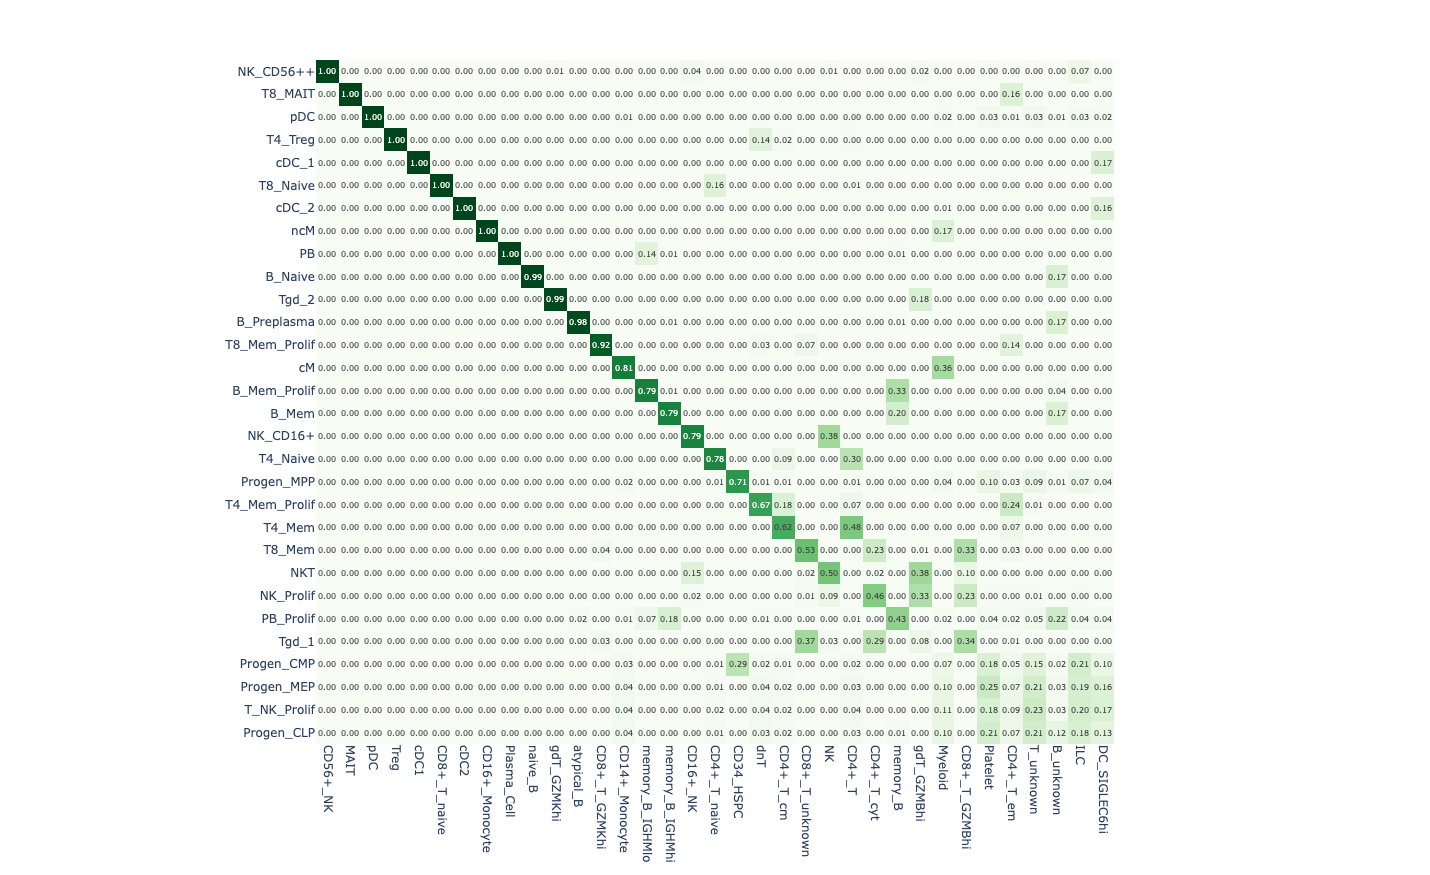

In [5]:
plot_cluster_mapping(mapping_precise)

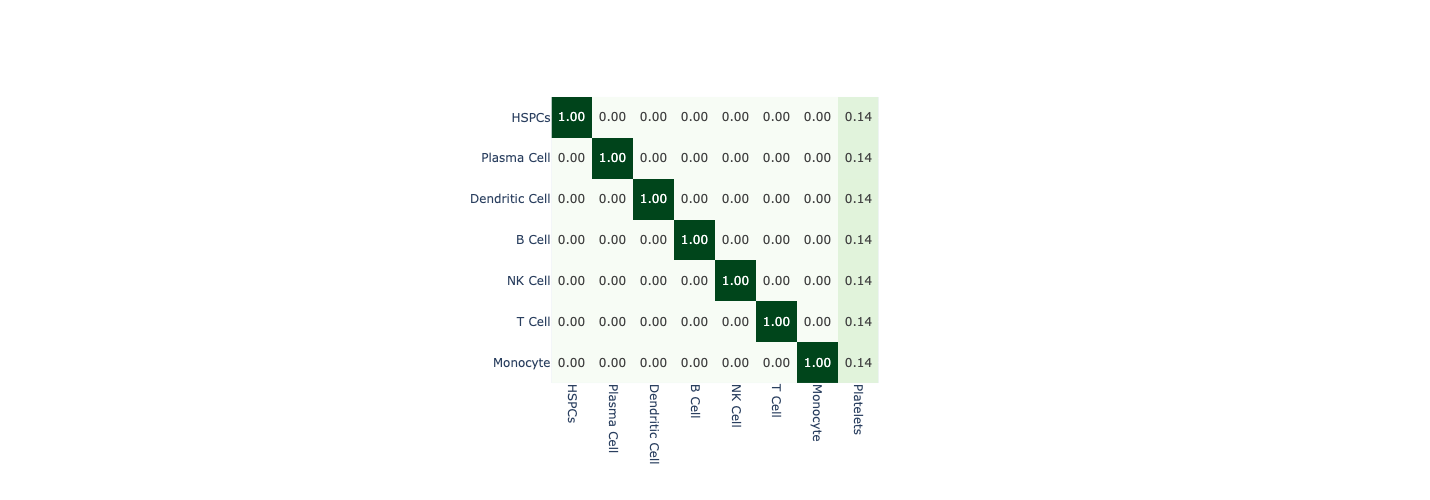

In [6]:
fig = plot_cluster_mapping(mapping_coarse, show=False)
fig.write_image("coarse_mappings_immune_example.svg")
fig

In [7]:
max_scores_coarse = (
    mapping_coarse.max(axis=0)
    .to_frame()
    .reset_index()
    .rename(columns={"index": "cell_type", 0: "max_score"})
)

max_scores_precise = (
    mapping_precise.max(axis=0)
    .to_frame()
    .reset_index()
    .rename(columns={"index": "cell_type", 0: "max_score"})
)

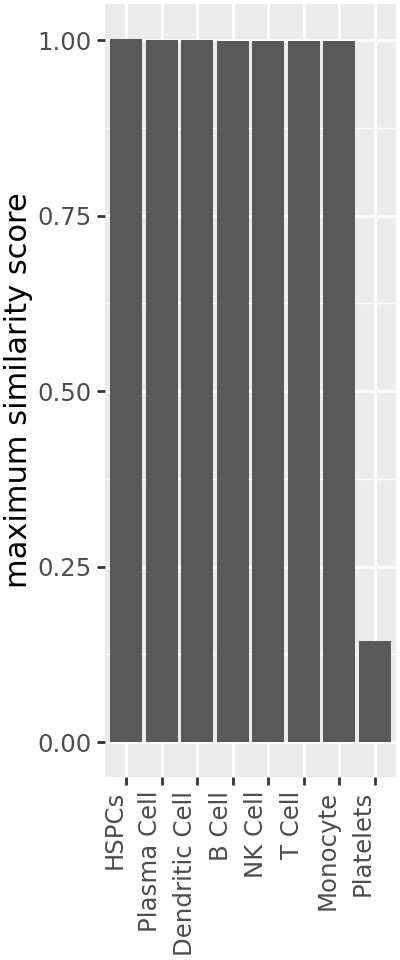

In [8]:
p_coarse = (
    ggplot(max_scores_coarse, aes(x="cell_type", y="max_score"))
    + scale_x_discrete(
        limits=max_scores_coarse.sort_values("max_score", ascending=False)["cell_type"].tolist()
    )
    + geom_col()
    + theme(
        figure_size=(2., 4.8),
        axis_title_x=element_blank(),
        axis_text_x=element_text(rotation=90, ha='right')
    )
    + ylab("maximum similarity score")
)

p_coarse

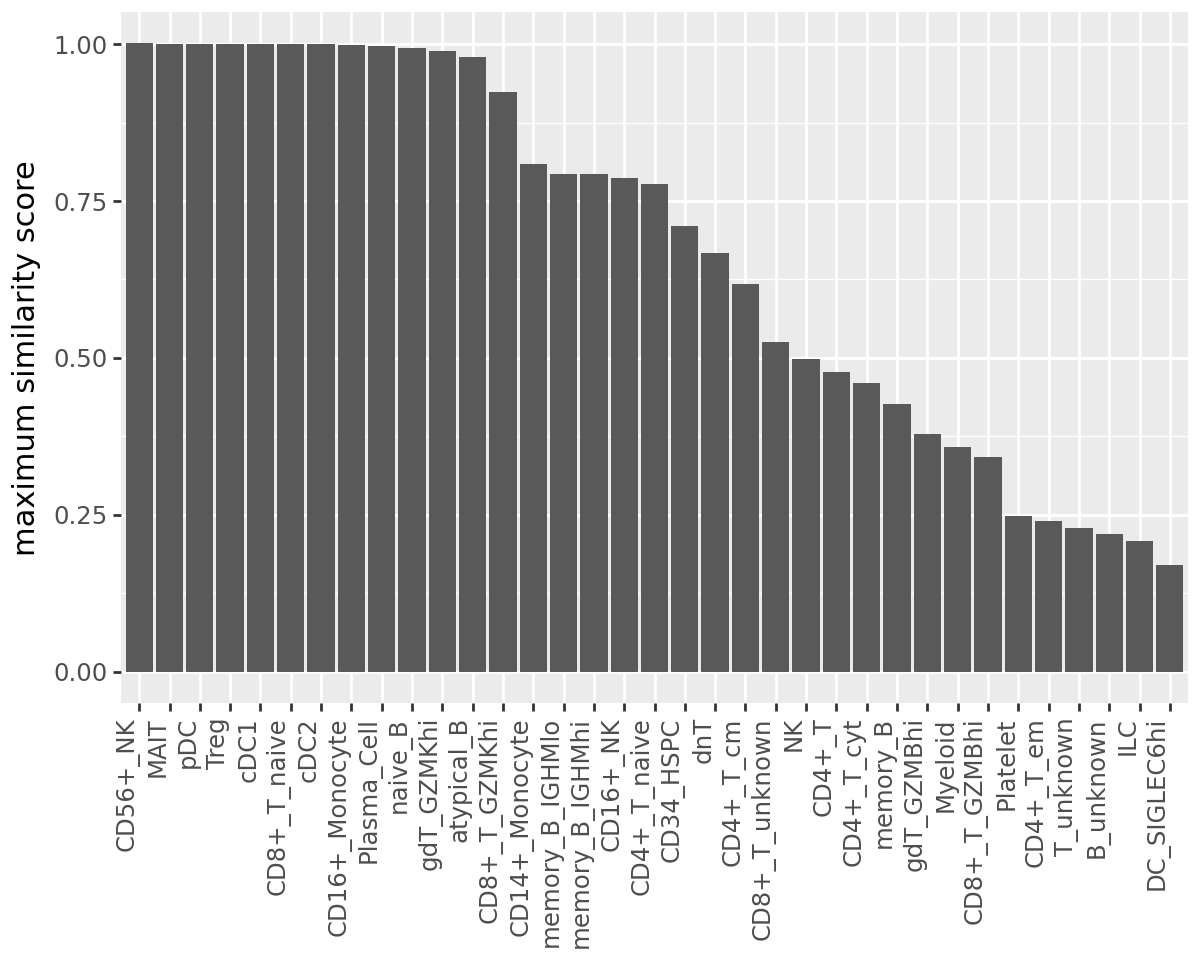

In [9]:
p_precise = (
    ggplot(
        max_scores_precise, 
        aes(x="cell_type", y="max_score")
    )
    + scale_x_discrete(
        limits=max_scores_precise.sort_values("max_score", ascending=False)["cell_type"].tolist()
    )
    + geom_col()
    + theme(
        figure_size=(6., 4.8),
        axis_title_x=element_blank(),
        axis_text_x=element_text(rotation=90, ha='right')
    )
    + ylab("maximum similarity score")
)
p_precise

## Plot distributions of mapping scores

In [10]:
QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d_coarse_annot"
REF_DATASETS = [
    "03f821b4-87be-4ff4-b65a-b5fc00061da7_PBMC_coarse_annot",
    "4f889ffc-d4bc-4748-905b-8eb9db47a2ed_coarse_annot",
    "b0cf0afa-ec40-4d65-b570-ed4ceacc6813_coarse_annot",
    "b9fc3d70-5a72-4479-a046-c2cc1ab19efc_coarse_annot",
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP_coarse_annot",
    "ddfad306-714d-4cc0-9985-d9072820c530_coarse_annot",
    "eb735cc9-d0a7-48fa-b255-db726bf365af_coarse_annot",
    "ed9185e3-5b82-40c7-9824-b2141590c7f0_coarse_annot",
]


dataset_names = {
    "03f821b4-87be-4ff4-b65a-b5fc00061da7_PBMC_coarse_annot": "Yoshida et al.",
    "4f889ffc-d4bc-4748-905b-8eb9db47a2ed_coarse_annot": "Lee et al.",
    "b0cf0afa-ec40-4d65-b570-ed4ceacc6813_coarse_annot": "Hao et al.",
    "b9fc3d70-5a72-4479-a046-c2cc1ab19efc_coarse_annot": "Jin et al.",
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP_coarse_annot": "Kock et al.",
    "ddfad306-714d-4cc0-9985-d9072820c530_coarse_annot": "Stephenson et al.",
    "eb735cc9-d0a7-48fa-b255-db726bf365af_coarse_annot": "CZI Covid-19 consortia",
    "ed9185e3-5b82-40c7-9824-b2141590c7f0_coarse_annot": "Liu et al.",
}

In [11]:
mappings = {
    dataset: load_mappings(DATA_PATH, QUERY_DATASET, dataset)
    for dataset in REF_DATASETS
}

In [12]:
def aggregate(df):
    return (
        df
        .max(axis=0)
        .to_frame()
        .reset_index()
        .rename(columns={"index": "cell_type", 0: "max_score"})
    )

dfs = []

for dataset, (precise, coarse) in mappings.items():
    dataset = dataset_names[dataset]
    dfs += [
        precise.pipe(aggregate).assign(dataset=dataset, granularity="precise"),
        coarse.pipe(aggregate).assign(dataset=dataset, granularity="coarse")
    ]

df_plot = pd.concat(dfs)

/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning:

Saving 10 x 5 in image.

/vol/data/miniconda3/envs/sconnect/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning:

Filename: scores_per_dataset.svg



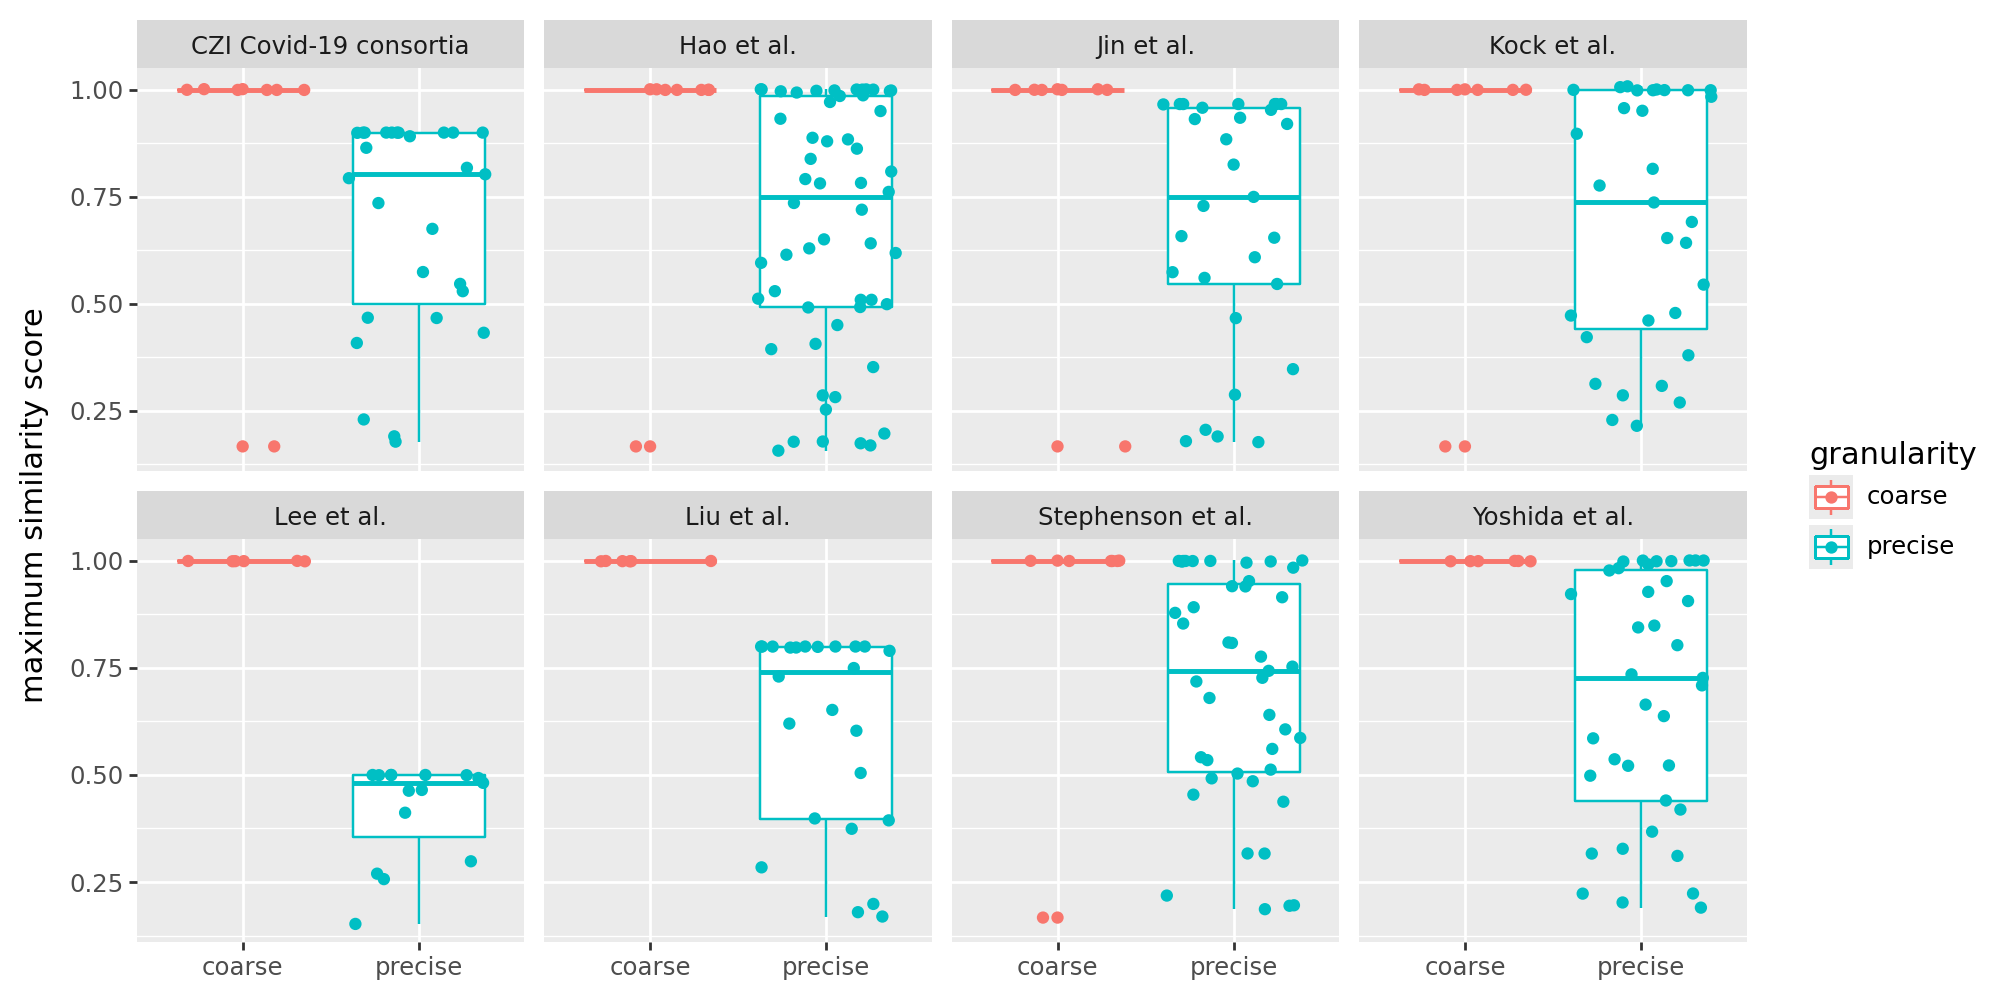

In [15]:
p = (
    ggplot(df_plot, aes("granularity", y="max_score", color="granularity"))
    + geom_boxplot()
    + geom_point(position=position_jitter())
    + facet_wrap("dataset", ncol=4)
    + theme(
        figure_size=(10, 5),
        axis_title_x=element_blank()
    )
    + ylab("maximum similarity score")
)
p.save("scores_per_dataset.svg")
p